In [2]:
import matplotlib.pyplot as plt 
import numpy as np
import IPython.display as ipd
from scipy.io import wavfile
import scipy as sp


<h2>Analog to Digital Conversion and Fast Fourier Transform </h2>

<h4>Introduction</h4>

<p>A world without music is unimaginable. But what is music really? It would be most appropriate to sum it up like this: music is something that we hear,
sounds that make up something complex, giving it a sonic shape which in most cases triggers an emotional response from us. But most of all music consists of sounds, just not any sounds as that would mean noise and music are the same thing. Fundamentally sounds are pressure variations in the air and our ears act like barometers for those variations. When they happen, invisible oscillations cause the air mollecules to react to those to them and some  group tightly together while others spread apart from one another, creating sound  waves. ( they are in their essence mechanical wave which means that they need a medium to propagate through, and as the energy of that wave travels from point A to point B this medium is deformed )</p>
<br>
<p>Most often we listen to our favourite bands in Youtube as we cannot see them play live every other day. This project consists of two parts and as a person totally unfamilliar with how sound works in an engineering sense my goal was to research the process and try to comprehend it so that I can illustrate it with the tools from our lectures. The first part aims to show the process of ADC, and the second one aims to show the process of creating a spectrogram and a fingerprint from the audio signal</p> <br><br>
<br>
**The process of ADC consists of the following steps:**

1. Generating a signal (this is for testing purposes of the project) – let's say we have a soundwave
2. Sampling the signal
3. Quantizing the signal
4. Binary encoding of the discrete values


**The process of creating a spectrogram and a fingerprint is quite complex and consists of the following steps:**

1. Short-Time Fourier Transform (STFT) – using built-in functions from `scipy`
2. Spectrogram generation
3. Peak detection
4. Creating a fingerprint hash

<h4>Analog signals</h4>
<br>
<p>The analog signal is a function continous in time that we use to describe mechanical waves, as they have a value in each moment in time. To be particular analog signals are described via the following function:</p> 
$$ x(t) = A\sin(2\pi f t - \phi) $$
<br> Where: <br>
$x(t)$ - signal value at time $𝑡$ <br>
$A$ - Amplitude of the signal which determines its maximum value <br>
$f$ - Frequency of the signal which represents the number of full cycles per unit of time (most often seconds) and is measured in Hz and is also denoted with the formula $f = \frac{1}{T}$ where $T$ is the period - the time it takes for the signal to reach from peak to peak <br>
$\phi$ - Phase ( in the formula it can be added or subtracted) and represents the offset and it tells us what is the position of the waveform at time 0
<br>
There is a simple rule: The higher the frequency, the higher the sound! Amplitude works in a similar way; the higher the Amplitude, the louder the sound!
<br><br>

In [3]:
#formula
sinusoid = lambda amplitude, frequency, phase, t: amplitude * np.sin(2*np.pi*(frequency*t - phase))

<h4>Generating a signal</h4>
<h5>The core idea of the first part is every output of a function is the input of the following one, much as the idea of a pipeline</h5>
<br>
This is how I create the curve of the sinusoid function. It is important to note that this is the simplest form - a periodic signal, where each sine wave has the same frequency. The output of this function is:
<br>
x  - the value of the signal of time $t$
<br>
t  - time

In [4]:
def generate_periodic_signal(duration, amplitude, frequency, phase, sampling_frequency_1, sinusoid):
     #measuring the signal at evenly spaced time points

     #from now on the sampling frequency 1 will always be higher as the curve is continous and in order to show it
     #the number of points it consists of would be higher than the actual sampling frequency used for equidistant sampling
     #maybe the naming of that should be different
    
     num_samples = int(sampling_frequency_1 * duration)
     t = np.arange(num_samples) / sampling_frequency_1
     #calculate the value by the formula
     x = sinusoid(amplitude, frequency, phase, t)
     return x, t


duration = 2
amplitude = 15
frequency = 25
phase  = 0
sampling_frequency_1 = 20000
sampling_frequency_2 = 100

x, t  = generate_periodic_signal(duration, amplitude, frequency, phase, sampling_frequency_1, sinusoid)

 <h4>Sampling the signal</h4>

Equidistant sampling or just sampling

<p>In simple terms this is the process of reducing a contionus in time signal $f(t) $to a discrete in time one. The sampling period is denoted in the following way: </p>
1. We choose a positive real number $T>0$  <br>
2. We create a discrete time signal $x(n) := f(n \cdot T), \quad n \in \mathbb{Z}$
<br>
<br>
$n$ - integer index $(n \in \mathbb{Z})$ or to put it simply the number of the sample
<br>
$nT$ - the actual time we sample
<br>
$x(n)$ - our sample
<br><br>
<p>What does that mean? Instead of every possible point ( calculated in my functions always using sampling_frequency_1) we, only take the value of
the continous signal **at specific points of time**</p>
<br>
<p>If we look closer at the sampled functions, we see that the levels are not precisely following the curve, there are areas that are either skipped, or included in the sample. This represents the error rate. Intuitively, higher sampling rate means less errors, lower sampling rate means more loss of information. </p>
<br>

<h4>Aliasing and the Nyquist theorem</h4>
<p>In general, no matter how precise we are and how high our sampling rate is, we lose some information in the process of discretization of the signal. Therefore, the original continuous-time signal cannot always be perfectly reconstructed from its sampled version. Only if the continuous time signal has additional properties in its frequency spectrum, specifically if it is bandlimited, perfect reconstruction becomes possible.</p>
<br>
*A signal is called bandlimited if its frequency spectrum contains no frequencies above a certain maximum frequency* $fmax$
<br><br>
<p>Here comes the role of the sampling theorem associated with the names of Harry Nyquist and Claude Shannon who state that such signal can be reconstructed under specific conditions: $$ F_s \ge 2f_{\max} $$</p>
$F_s$ - sampling frequency 
$f_{\max}$ - highest frequency of a signal
<br>
How does this help us? Without additional properties, sampling may cause an effect known as aliasing where certain frequency components of the signal become indistinguishable


In [5]:
# add nyquist theorem validation
def sample_signal(t, x, duration, sampling_frequency_2, max_frequency):
     Nyquist_sampling_rate = 2*max_frequency
     if sampling_frequency_2 < Nyquist_sampling_rate:
         print(f"{RED}The sampling rate to successfully reconstruct this signal according to the Nyquist theorem is {Nyquist_sampling_rate}{RESET}")
     
     num_samples_2 = int(sampling_frequency_2 * duration)
     t_discrete = np.arange(num_samples_2) / sampling_frequency_2
     x_discrete = np.interp(t_discrete, t, x)
     return x_discrete, t_discrete

#max frequency is just 4 since it's a periodic sinusoid
x_discrete, t_discrete = sample_signal(t, x, duration, sampling_frequency_2, frequency)

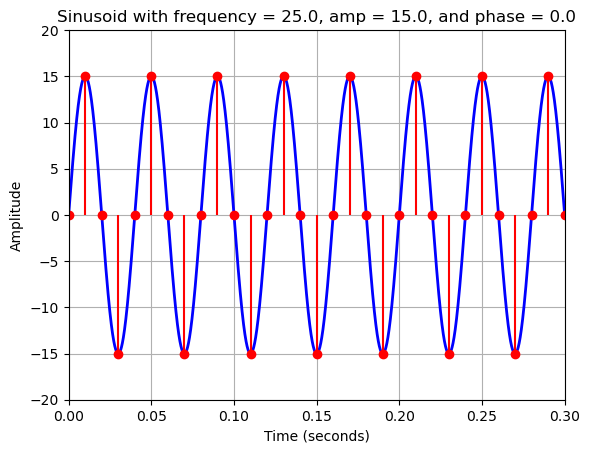

In [6]:

def display_graph(x, t, x2, t2, label, x_lim, a_lim):
     plt.plot(t, x, color='blue', linewidth=2.0, linestyle='-')
     plt.xlim(x_lim)
     plt.ylim(a_lim)
     plt.xlabel('Time (seconds)')
     plt.ylabel('Amplitude')
     plt.title(label)
     plt.stem(t2, x2, linefmt='r', markerfmt='ro', basefmt='None')
     plt.grid()
     plt.show()


label = 'Sinusoid with frequency = %.1f, amp = %.1f, and phase = %.1f' % (frequency, amplitude, phase)
display_graph(x, t, x_discrete, t_discrete, label, [0, 0.3], [-20, 20])


<p>This is what plotting a very simple periodic signal looks like for one second. Player wouldn't play that for frequencies lower than 20 as the hearing range of human has the the scope of  20 Hz – 20,000 Hz. </p>

In [7]:
    
def hear_signal(x, sampling_frequency, rate_scale = 1):
    rate = int(sampling_frequency * rate_scale)
    #x = x / np.max(np.abs(x))
    ipd.display(ipd.Audio(x, rate=rate))
    
hear_signal(x, sampling_frequency_1)


<h5>Composite analog signals</h5>
<p>Firstly, a composite periodic analog signal is composed of multiple sine waves. However composite signals can be periodic and aperiodic; There are a couple of very important differences between these two types:</p> 

1. Aperiodic signals do not exhibit any repetitive pattern, while composite periodic signals have repetitive patterns at regular intervals
2. While for periodic signals applies the rule $ x(t) = x(t + T)$ where $T$ is the period, for aperiodic signals no fixed period exists
3. **Very important!!!** Periodic signals are represented by a *Fourier series (sum of sinusoidal components)* whereas aperiodic signals require *Fourier transformation* for spectral representation.
4. Most importantly - speech and music, and many other sounds we hear are primarily aperiodic.

 <p> In order to plot them, similarly to our generate_periodic_signal, we are going to define a function that generates composite aperiodic signals.</p>

In [8]:
# we rely on numbered and named args in order to work with the different input params of the lambdas that we will use in order 
# to generate aperiodic signals, because their formulas are different than the sine one.
def generate_signal(duration, sampling_frequency, signal_function, *args, **kwargs):
    num_samples = int(sampling_frequency * duration)
    t = np.arange(num_samples) / sampling_frequency
    x = signal_function(*args, t=t, **kwargs)
    return x, t

exponential_decay_sinusoid = lambda amplitude, frequency, phase, decay, t: amplitude * np.exp(-decay * t) * np.sin(2*np.pi*(frequency*t - phase))
gaussian_pulse = lambda amplitude, center, width, t: amplitude * np.exp(-((t-center)**2) / (2*width**2))


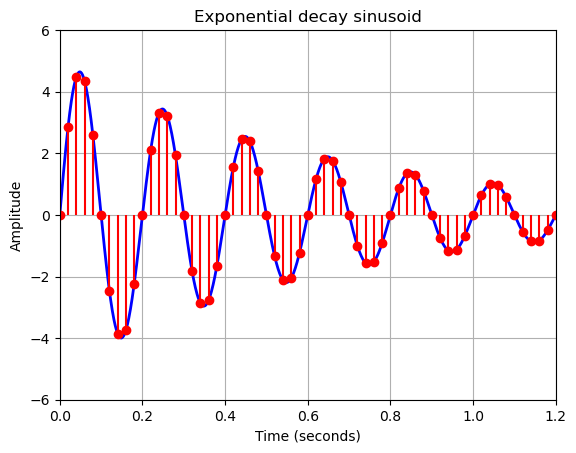

In [9]:
x_exponential_decay, t_exponential_decay = generate_signal(
    duration=3,
    sampling_frequency = 1000,
    signal_function = exponential_decay_sinusoid,
    amplitude = 5,
    frequency = 5,
    phase = 0,
    decay = 1.5
)
x_exponential_discrete, t_exponential_discrete = sample_signal(t_exponential_decay, x_exponential_decay, 3, 50, 5);
display_graph(x_exponential_decay, t_exponential_decay, x_exponential_discrete, t_exponential_discrete, "Exponential decay sinusoid", [0, 1.2], [-6, 6])

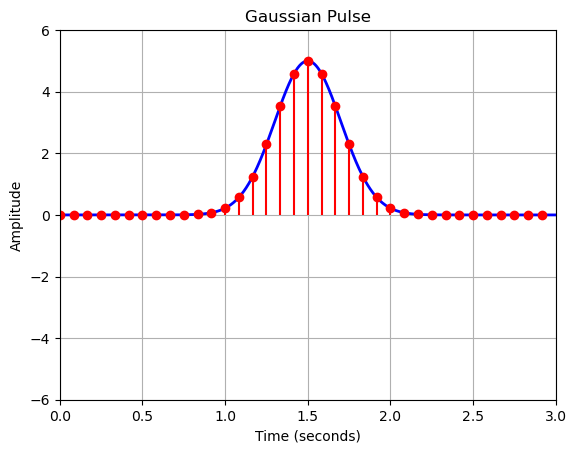

In [10]:
x_gaussian, t_gaussian = generate_signal(
    duration = 3,
    sampling_frequency = 1000,
    signal_function = gaussian_pulse,
    amplitude = 5,
    center = 1.5,
    width = 0.2
)
x_gaussian_discrete, t_gaussian_discrete = sample_signal(t_gaussian, x_gaussian, 3, 12, 5);
display_graph(x_gaussian, t_gaussian, x_gaussian_discrete, t_gaussian_discrete, "Gaussian Pulse", [0, 3], [-6, 6])

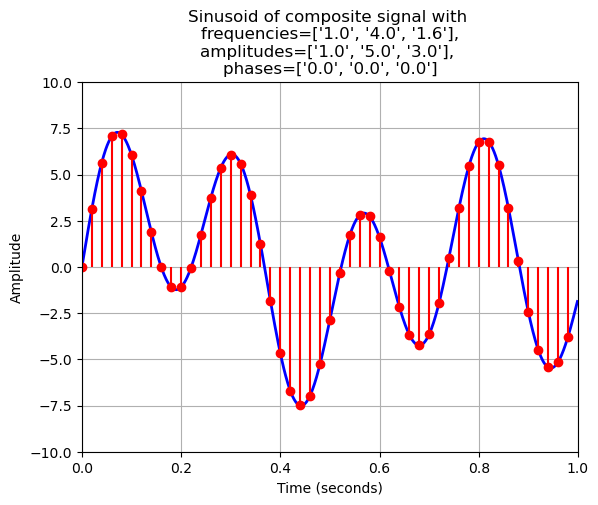

In [11]:
# since we have a repetetive pattern we can use a matrix to pass the different sinusoidal components, then we transpone it 
# and we generate part of the function and add it to the sum of points, and each row of that matrix has an amplitude, a frequency and a phase
# despite being created from multiple different sine waves, the sampling frequency remains the same as we still want to know how x(t) changes
# in equal intervals of time.

def generate_composite_periodic_signal(amplitudes, frequencies, phases, sinusoid, duration, sampling_frequency_1):
    signal_matrix = np.array([amplitudes, frequencies, phases]).T
    x_total = None
    t = None
    N = int(sampling_frequency_1 * duration)
    t = np.arange(N) / sampling_frequency_1
    for row in signal_matrix:
        amplitude, frequency, phase = row
        x  = sinusoid(amplitude, frequency, phase, t)
        if x_total is None:
                x_total = x
        else:
                x_total += x
    return x_total, t


amplitudes  = [1,5,3]
frequencies = [1,4,1.6]
phases      = [0, 0, 0]
sampling_frequency_composite = 1000
sampling_frequency_composite_2 = 50
duration = 1

max_frequency_composite = max(frequencies)
x_composite, t_composite = generate_composite_periodic_signal(amplitudes, frequencies, phases, sinusoid, duration, sampling_frequency_composite)
x_discrete_composite, t_discrete_composite = sample_signal(t_composite, x_composite, duration, sampling_frequency_composite_2,  max_frequency_composite)
label = (
    "Sinusoid of composite signal with "
    f"\nfrequencies={[f'{f:.1f}' for f in frequencies]},"
    f"\namplitudes={[f'{a:.1f}' for a in amplitudes]}, "
    f"\nphases={[f'{p:.1f}' for p in phases]}"
    )
display_graph(x_composite, t_composite, x_discrete_composite, t_discrete_composite, label, [0, 1], [-10,10] )


<h4>Quantization</h4>
<p>In order to discuss ADC we have to understand what a digital signal is: it is the representation of a sound which contains all information encoded in order for us to reproduce the sound it represents. How does this representation of an analog signal happen with 0s and 1s? One of the problems we face is that since the signal is a function continuous in time is actually the resolution - we can never be precise enough to describe what the value of the signal is at time seconds, milliseconds, etc. We  have to accept the error rate after all. First step of the ADC is the sampling as mentioned above. Quantization works in a similar way, but instead of sampling on the x axis ( meaning time ) we sample vertically ( by Amplitude ). In the process of quantization we are using bits </p>

<p>The resolution (**bit depth**) for a CD is 16 so that is why this is the the value of the optional arg of the function below. To sum up, we apply a quantization step over amplitude values according to the formula: $$q = \frac{x_{\max} - x_{\min}}{L}$$<br>

$L$ = quantization levels, calculated by raising 2 by the power of the bit depth  <br>
$x_\max $ - maximumam amplitude value <br>
$x_\min $ - minimum amplitude value<br>
</p>

In [12]:
#cd audio is 16 bits so it is acceptable
def quantize_signal(x_discrete, bits = 16):
    #bits = bit depth
    levels = 2**bits
    x_min = np.min(x_discrete)
    x_max = np.max(x_discrete)
    q = (x_max - x_min) / levels
    x_quantized = q * np.round(x_discrete / q)
    return x_quantized

In [13]:
def show_quantized_signal(x_quantized, t_discrete, x, t, x_lim = None, a_lim = None):
    if x_lim is None:
        x_lim = [t[0], t[-1]]
    if a_lim is None:
        max_amp = max(abs(x).max(), abs(x_quantized).max())
        a_lim = [-1.2 * max_amp, 1.2 * max_amp]
    plt.xlim(x_lim)
    plt.ylim(a_lim)
    plt.plot(t, x, label="Analog signal")
    plt.step(t_discrete, x_quantized, where='mid', label="Digital signal")
    plt.legend()
    plt.grid()
    plt.show()


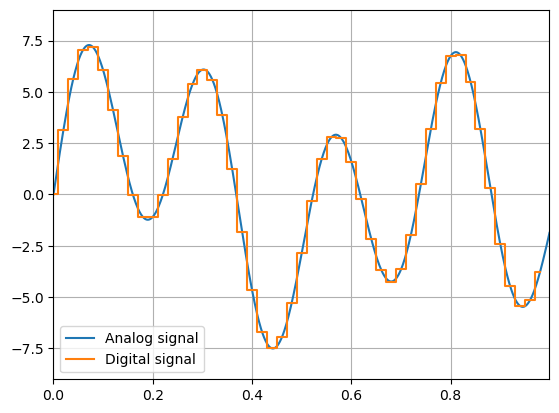

In [14]:
x_quantized_composite = quantize_signal(x_discrete_composite)
show_quantized_signal(x_quantized_composite, t_discrete_composite, x_composite, t_composite)

<p>Since sampling can be explained by discretization of time, quantization can be explained as discretization by amplitude. Each step represents the level of quantization, and computing it means that the analog value must be rounded to the nearest discrete value. </p>

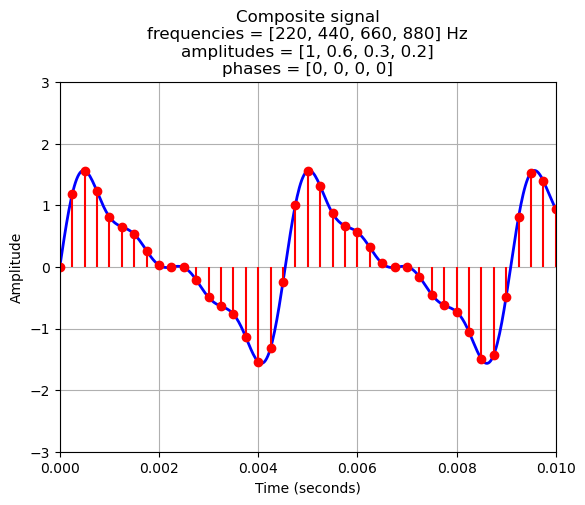

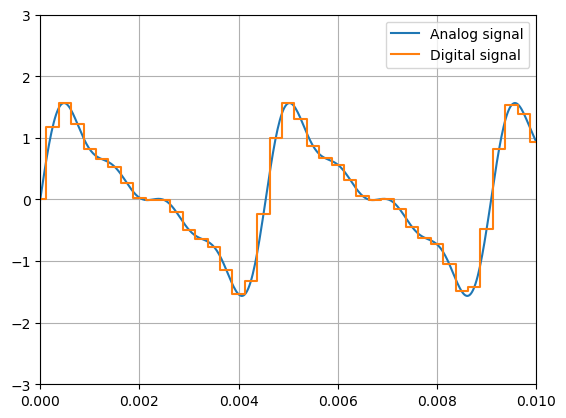

In [15]:
amplitudes_real  = [1, 0.6, 0.3, 0.2]
frequencies_real = [220, 440, 660, 880]
phases_real      = [0, 0, 0, 0]

sampling_frequency_composite_real = 44100
sampling_frequency_composite_2_real = 4000
duration_real = 1

max_frequency_real  = max(frequencies_real)

x_composite_real, t_composite_real = generate_composite_periodic_signal(
    amplitudes_real,
    frequencies_real,
    phases_real,
    sinusoid,
    duration_real,
    sampling_frequency_composite_real
)

x_discrete_composite_real, t_discrete_composite_real = sample_signal(
    t_composite_real,
    x_composite_real,
    duration_real,
    sampling_frequency_composite_2_real,
    max_frequency_real
)


label_real = (
    "Composite signal\n"
    f"frequencies = {[round(f,1) for f in frequencies_real]} Hz\n"
    f"amplitudes = {[round(a,2) for a in amplitudes_real]}\n"
    f"phases = {[round(p,1) for p in phases_real]}"
)


display_graph(
    x_composite_real,
    t_composite_real,
    x_discrete_composite_real,
    t_discrete_composite_real,
    label_real,
    [0, 0.01],
    [-3, 3]
)

x_quantized_composite_real = quantize_signal(x_discrete_composite_real)
show_quantized_signal(x_quantized_composite_real, t_discrete_composite_real, x_composite_real, t_composite_real, [0, 0.01], [-3, 3])

<h4>FFT, Spectrograms and Fingerprinting</h4>
<p>Now, that we know what the first part of signal processing is, comes the role of FFT which is the most fundamental concept in the theory of signals. There is a significant difference between the Fourier Series and the Fourier transformation that will be explained futher on. </p>
<h5>Fourier Transform</h5>
<p>FT allows us to analyze sounds by their frequencies rather than just by the shape of their soundwave, since it is usually made up of various types of signals and the FT allows us to separate them and extract the information we want from each one of them.</p>
$$F(\omega) = \int_{-\infty}^{\infty} f(x)e^{-i\omega x}\,dx$$
<p>To understand what does the Fourier Transform do we need to answer the following questions: </p>
1. What is exactly that the Fourier transform does? <br>
It takes a signal $f(x)$, and in order to decompose it into frequencies, it maps every frequency $\omega$ to a complex exponential $e^{-i\omega x}$
<br><br>
2. What is the role of Euler's number in this formula? <br>
Euler's formula maps the complex exponentials to real sinusoids:  <br>
$e^{j\omega t} = \cos(\omega t) + j\sin(\omega t)$ and this makes it possible for any sinusoid to be expressed using a real component and an imaginary component ( roating phasors )<br><br>
3. Since it has an imaginary part, what do we get as a result from Fourier Transformation? <br>
If x(t) is real, the Fourier transform produces complex coefficients: <br>
$A(\omega)$ - the magnitude is the strength of the frequency in dB <br>
$\Phi(\omega)$ - the phase <br>
<br><br>

In [16]:
def compute_fft(x, sampling_frequency):
    N = len(x)
    X = np.fft.fft(x)
    frequencies = np.fft.fftfreq(N, d = 1/sampling_frequency)
    magnitudes = np.abs(X)
    frequencies = frequencies[:N//2]
    magnitudes = magnitudes[:N//2]
    return frequencies, magnitudes, N, X

In [17]:
fft_composite_real, magnitudes_real, N, X = compute_fft(x_quantized_composite_real, sampling_frequency_composite_2_real)


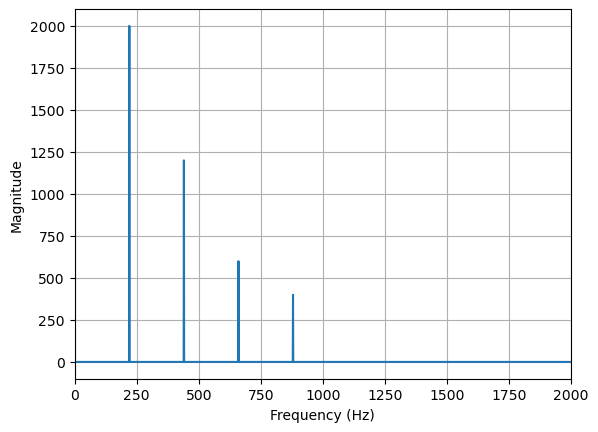

In [18]:
def show_spectrogram(frequencies, magnitudes, sampling_frequency, x_lim = None, y_lim = None):
    plt.plot(frequencies, magnitudes)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    if(x_lim == None):
        plt.xlim([0, 2000])
    else:
        plt.xlim(x_lim)

    if(y_lim != None):
        plt.ylim(y_lim)
    plt.grid()
    plt.show()

show_spectrogram(fft_composite_real, magnitudes_real, sampling_frequency_composite_2_real)

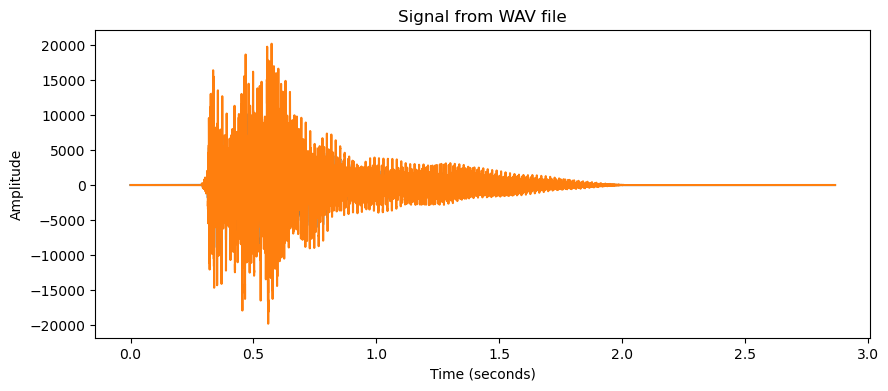

44100


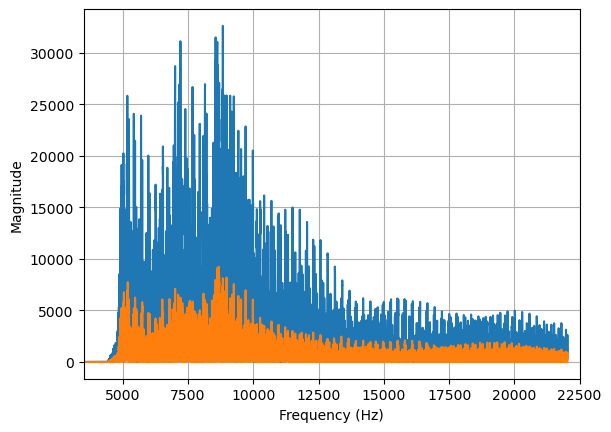

In [21]:
sampling_frequency_wav, signal = wavfile.read('lgs.wav');
wav_time = np.arange(len(signal)) / sampling_frequency_wav
plt.figure(figsize=(10,4))
plt.plot(wav_time, signal)
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Signal from WAV file")
plt.show()


wav_fft_frequencies, wav_magnitudes, N, X = compute_fft(signal, sampling_frequency_wav)
print(sampling_frequency_wav)
show_spectrogram(wav_fft_frequencies,  wav_magnitudes, sampling_frequency_wav, [3500, 22500] )

In [ ]:
#finger printing is done using SFFT

def compute_sfft(x, sampling_frequency):
    ff, tt, Sxx = sp.signal.spectrogram(
        x,
        sampling_frequency,
        nperseg = 1024,
        noverlap = 768
    )
    Sxx_log = 10 * np.log10(Sxx + 1e-10)
    return ff, tt, Sxx, Sxx_log
    

In [ ]:
def plot_sfft_spectrogram(ff, tt, Sxx):
    plt.figure(figsize=(10,6))
    plt.pcolormesh(tt, ff, Sxx)
    plt.xlabel("Time (seconds)")
    plt.ylabel("Frequency (Hz)")
    plt.title("Spectrogram")
    plt.colorbar(label="Intensity (dB)")

    plt.show()

In [ ]:
if signal.ndim > 1:
    signal = signal.mean(axis=1)

ff, tt, Sxx, Sxx_log = compute_sfft(signal, sampling_frequency_wav)

In [ ]:
plot_sfft_spectrogram(ff, tt, Sxx_log)

In [ ]:
def extract_peaks(Sxx_log, threshold=10):
    peaks = sp.ndimage.maximum_filter(Sxx_log, size=10) == Sxx_log
    rows, cols = np.where(peaks)
    peaks = [(col, row) for col, row in zip(cols, rows) if Sxx_log[row, col] > threshold]
    return peaks

In [ ]:
def visualize_peaks(ff, tt, Sxx_log, peaks):
    plt.figure(figsize=(12,8))
    plt.pcolormesh(tt, ff, Sxx_log, shading='auto')
    plt.scatter( [tt[p[0]] for p in peaks], [ff[p[1]] for p in peaks], color='red', s=10, label="Peaks");
    plt.xlabel("Time (seconds)")
    plt.ylabel("Frequency (Hz)")
    plt.title("Spectrogram with Peaks")
    plt.colorbar(label="Intensity (dB)")
    plt.legend()
    plt.show()   

In [ ]:
peaks =  extract_peaks(Sxx_log);
visualize_peaks(ff, tt, Sxx_log, peaks)

In [ ]:
def create_fingerprint():
    print('Find algorithm to create fingerprint')
    